# Attack Success Rate vs. Perturbation Budget

`01_attack_comparison.ipynb` compares HotFlip and Synonym Substitution at one fixed budget each (5 flips, 10 substitutions). That leaves an open question neither notebook answers: how much of each attack's final success rate is already reached at a much smaller budget, and does either one keep climbing all the way to its cap, or does it plateau early? This is the text analogue of the vision repo's epsilon sweeps (`robustness_evaluation/05_accuracy_vs_perturbation.ipynb`, `06_epsilon_sweep.ipynb`): instead of a continuous perturbation magnitude, the budget here is a discrete count, HotFlip's number of allowed word flips and Synonym Substitution's number of allowed word substitutions.

In [1]:
import time
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

import torch
import torch.nn.functional as F
import nltk
from nltk.corpus import wordnet, stopwords
from transformers import AutoTokenizer, AutoModelForSequenceClassification

nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('stopwords', quiet=True)
STOPWORDS = set(stopwords.words('english'))

### Setup
Same target model and the same real-sample convention as `01_attack_comparison.ipynb`, kept to a
smaller sample here since every sentence gets attacked once per budget value instead of just once.

In [2]:
MODEL_NAME = 'distilbert-base-uncased-finetuned-sst-2-english'
SAMPLE_SIZE = 10

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()
LABELS = model.config.id2label

sst2 = load_dataset('stanfordnlp/sst2', split='validation')
sentences = [s for s in sst2['sentence'][:SAMPLE_SIZE * 2] if len(s.split()) >= 5][:SAMPLE_SIZE]
print(f"Loaded {len(sentences)} SST-2 validation sentences")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded 10 SST-2 validation sentences


### The Two Attacks
Identical implementations to `attacks/whitebox/01_HotFlip.ipynb` and `attacks/blackbox/01_SynonymSubstitution.ipynb`, unchanged, just called here with a range of budget values instead of one fixed one.

In [3]:
@torch.no_grad()
def predict(text):
    inputs = tokenizer(text, return_tensors='pt')
    probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    label_idx = int(torch.argmax(probs))
    return LABELS[label_idx], float(probs[label_idx]), label_idx

@torch.no_grad()
def predict_proba(text, label_idx):
    inputs = tokenizer(text, return_tensors='pt')
    probs = F.softmax(model(**inputs).logits, dim=-1)[0]
    return float(probs[label_idx])

embedding_matrix = model.get_input_embeddings().weight
SPECIAL_TOKEN_IDS = set(tokenizer.all_special_ids)

def hotflip_step(input_ids, true_label_idx):
    embeds = embedding_matrix[input_ids].clone().detach().unsqueeze(0)
    embeds.requires_grad_(True)
    logits = model(inputs_embeds=embeds).logits
    loss = F.cross_entropy(logits, torch.tensor([true_label_idx]))
    loss.backward()
    grad = embeds.grad[0]

    best_score, best_pos, best_candidate = float('-inf'), None, None
    for pos in range(len(input_ids)):
        if input_ids[pos].item() in SPECIAL_TOKEN_IDS:
            continue
        current_embed = embedding_matrix[input_ids[pos]]
        scores = (embedding_matrix - current_embed) @ grad[pos]
        candidate_id = int(torch.argmax(scores))
        if scores[candidate_id] > best_score:
            best_score = float(scores[candidate_id])
            best_pos, best_candidate = pos, candidate_id
    return best_pos, best_candidate

def hotflip_attack(text, max_flips=5):
    input_ids = tokenizer(text, return_tensors='pt')['input_ids'][0]
    _, _, true_label_idx = predict(text)
    n_flips = 0
    for _ in range(max_flips):
        pos, candidate_id = hotflip_step(input_ids, true_label_idx)
        input_ids = input_ids.clone()
        input_ids[pos] = candidate_id
        n_flips += 1
        adv_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        _, _, current_label_idx = predict(adv_text)
        if current_label_idx != true_label_idx:
            break
    return tokenizer.decode(input_ids, skip_special_tokens=True), n_flips

POS_MAP = {'NN': wordnet.NOUN, 'VB': wordnet.VERB, 'JJ': wordnet.ADJ, 'RB': wordnet.ADV}

def get_synonyms(word, pos_tag, max_candidates=8):
    wn_pos = POS_MAP.get(pos_tag[:2])
    if wn_pos is None:
        return []
    synonyms = set()
    for syn in wordnet.synsets(word, pos=wn_pos):
        for lemma in syn.lemmas():
            candidate = lemma.name().replace('_', ' ')
            if candidate.lower() != word.lower():
                synonyms.add(candidate)
    return list(synonyms)[:max_candidates]

def synonym_attack(text, max_words_to_replace=10):
    words = text.split()
    pos_tags = [tag for _, tag in nltk.pos_tag(words)]
    _, _, true_label_idx = predict(text)

    base_prob = predict_proba(text, true_label_idx)
    queries_used = 1
    importances = []
    for i in range(len(words)):
        if words[i].lower() in STOPWORDS:
            importances.append((i, -1.0))
            continue
        without_word = words[:i] + words[i + 1:]
        prob_without = predict_proba(' '.join(without_word), true_label_idx)
        queries_used += 1
        importances.append((i, base_prob - prob_without))
    order = [i for i, _ in sorted(importances, key=lambda x: x[1], reverse=True)]

    n_substitutions = 0
    for count, i in enumerate(order):
        if count >= max_words_to_replace:
            break
        current_prob = predict_proba(' '.join(words), true_label_idx)
        queries_used += 1
        best_word, best_prob = words[i], current_prob
        for candidate in get_synonyms(words[i], pos_tags[i]):
            trial_words = words[:i] + [candidate] + words[i + 1:]
            trial_prob = predict_proba(' '.join(trial_words), true_label_idx)
            queries_used += 1
            if trial_prob < best_prob:
                best_word, best_prob = candidate, trial_prob
        if best_word != words[i]:
            words[i] = best_word
            n_substitutions += 1
        _, _, current_label_idx = predict(' '.join(words))
        if current_label_idx != true_label_idx:
            break
    return ' '.join(words), n_substitutions, queries_used

### Sweeping the Budget
Every sentence is attacked once per budget value, for both attacks, using the model's own clean
prediction as the reference label. `HOTFLIP_BUDGETS` and `SYNONYM_BUDGETS` are on different scales
on purpose, matching each attack's own natural unit: HotFlip rarely needs more than a handful of
flips, Synonym Substitution routinely spends its budget on stopword-adjacent words that do not move
the prediction, so it needs a wider range to show a real curve.

In [4]:
HOTFLIP_BUDGETS = [1, 2, 3, 5, 8]
SYNONYM_BUDGETS = [1, 2, 3, 5, 8, 10]

rows = []
for sentence in sentences:
    _, _, true_label_idx = predict(sentence)

    for budget in HOTFLIP_BUDGETS:
        start = time.time()
        adv_text, n_flips = hotflip_attack(sentence, max_flips=budget)
        _, _, adv_label_idx = predict(adv_text)
        rows.append({
            'Attack': 'HotFlip', 'Budget': budget, 'Success': adv_label_idx != true_label_idx,
            'Actual_Perturbation': n_flips, 'Time_Sec': time.time() - start,
        })

    for budget in SYNONYM_BUDGETS:
        start = time.time()
        adv_text, n_subs, queries = synonym_attack(sentence, max_words_to_replace=budget)
        _, _, adv_label_idx = predict(adv_text)
        rows.append({
            'Attack': 'Synonym Substitution', 'Budget': budget, 'Success': adv_label_idx != true_label_idx,
            'Actual_Perturbation': n_subs, 'Time_Sec': time.time() - start,
        })

results_df = pd.DataFrame(rows)
results_df.to_csv('budget_sweep.csv', index=False)
print(f"Evaluated {len(sentences)} sentences x ({len(HOTFLIP_BUDGETS)} HotFlip + {len(SYNONYM_BUDGETS)} Synonym) budget values")

C:\Users\frang\AppData\Local\Temp\ipykernel_23364\4098843221.py:33: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:821.)
  best_score = float(scores[candidate_id])


Evaluated 10 sentences x (5 HotFlip + 6 Synonym) budget values


### ASR vs. Budget: Does More Perturbation Keep Paying Off?
If an attack's curve flattens well before its maximum tested budget, most of its power comes from a
handful of well-chosen changes, not from brute-forcing many; if it keeps climbing, budget itself is
still the bottleneck.

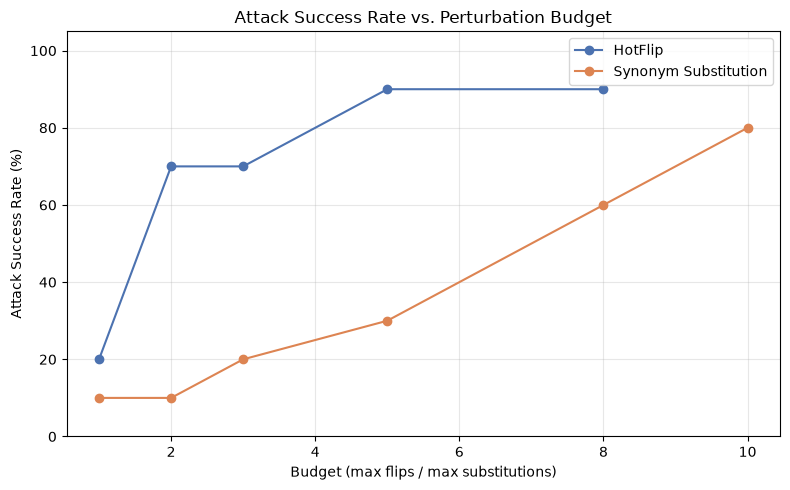

Attack,HotFlip,Synonym Substitution
Budget,,
1,20.0,10.0
2,70.0,10.0
3,70.0,20.0
5,90.0,30.0
8,90.0,60.0
10,NaN,80.0


In [5]:
summary = results_df.groupby(['Attack', 'Budget'])['Success'].mean().reset_index()
summary['ASR'] = summary['Success'] * 100

plt.figure(figsize=(8, 5))
for attack_name, color in [('HotFlip', '#4C72B0'), ('Synonym Substitution', '#DD8452')]:
    subset = summary[summary['Attack'] == attack_name]
    plt.plot(subset['Budget'], subset['ASR'], 'o-', label=attack_name, color=color)
plt.xlabel('Budget (max flips / max substitutions)')
plt.ylabel('Attack Success Rate (%)')
plt.title('Attack Success Rate vs. Perturbation Budget')
plt.ylim(0, 105)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

summary.pivot(index='Budget', columns='Attack', values='ASR').round(1)